<a href="https://colab.research.google.com/github/clobos/Alimentos_2026/blob/main/semana07_Alimentos_Modelos_Discretos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Configuração visual do gráfico
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# DISTRIBUIÇÃO DE BERNOULLI

 Aplicação: Inspeção de Qualidade Sensorial / Segurança Alimentar
 Cenário: Avaliação do selo de vedação de uma embalagem individual de leite UHT.
 Uma embalagem inspecionada está com defeito (sucesso = 1) ou conforme (fracasso = 0).



### Fórmula da Distribuição de Bernoulli

A Função Massa de Probabilidade (FMP) de uma variável aleatória de Bernoulli $X$ é dada por:

$P(X=k) = p^k (1-p)^{1-k} \quad \text{para } k \in \{0, 1\}$

em que:
- $p$ é a probabilidade de sucesso.
- $1-p$ é a probabilidade de fracasso.
- $k$ é o resultado (0 para fracasso, 1 para sucesso).

### Suporte da Variável Aleatória de Bernoulli

Os possíveis valores que uma variável aleatória de Bernoulli pode assumir são: $k \in \{0, 1\}$.

In [ ]:
print("--- 1. MODELO DE BERNOULLI ---")
p_defeito = 0.08  # Histórico da linha: 8% de chance de defeito na vedação

# Instância da variável aleatória de Bernoulli
bernoulli = stats.bernoulli(p=p_defeito)

prob_conforme = bernoulli.pmf(0)  # P(X = 0)
prob_defeito = bernoulli.pmf(1)   # P(X = 1)

print(f"Probabilidade de Embalagem Conforme (0): {prob_conforme:.2%}")
print(f"Probabilidade de Embalagem Defeituosa (1): {prob_defeito:.2%}\n")




--- 1. MODELO DE BERNOULLI ---
Probabilidade de Embalagem Conforme (0): 92.00%
Probabilidade de Embalagem Defeituosa (1): 8.00%




# DISTRIBUIÇÃO BINOMIAL

 Aplicação: Controle Estatístico do Processo (CEP) em Linhas de Envasamento
 Cenário: Um lote com n = 15 latas de conserva é amostrado.
 Sabendo que a taxa de inconformidade do processo é de 10% (p = 0.10),
 qual a distribuição do número de latas defeituosas no lote?



### Fórmula da Distribuição Binomial

A Função Massa de Probabilidade (FMP) de uma variável aleatória Binomial $X$ é dada por:

$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k} \quad \text{para } k \in \{0, 1, 2, \dots, n\}$

em que:
- $n$ é o número de tentativas independentes.
- $p$ é a probabilidade de sucesso em uma única tentativa.
- $k$ é o número de sucessos desejados.
- $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ é o coeficiente binomial.

### Suporte da Variável Aleatória Binomial

Os possíveis valores que uma variável aleatória Binomial pode assumir são: $k \in \{0, 1, 2, \dots, n\}$.

In [ ]:

print("--- 2. MODELO BINOMIAL ---")
n_latas = 15
p_inconforme = 0.10

binomial = stats.binom(n=n_latas, p=p_inconforme)

# Pergunta 1: Probabilidade de encontrar EXATAMENTE 2 latas defeituosas
prob_exatas_2 = binomial.pmf(2)

# Pergunta 2: Probabilidade do lote ser REJEITADO caso o critério seja ter 3 ou mais latas defeituosas: P(X >= 3)
prob_rejeicao = 1 - binomial.cdf(2)

print(f"Probabilidade de exatamente 2 latas defeituosas: {prob_exatas_2:.2%}")
print(f"Probabilidade de rejeição do lote (>= 3 defeituosas): {prob_rejeicao:.2%}\n")




--- 2. MODELO BINOMIAL ---
Probabilidade de exatamente 2 latas defeituosas: 26.69%
Probabilidade de rejeição do lote (>= 3 defeituosas): 18.41%




# DISTRIBUIÇÃO DE POISSON

 Aplicação: Microbiologia de Alimentos / Controle de Higiene
 Cenário: Contagem de Unidades Formadoras de Colônia (UFC) de Staphylococcus aureus
 em superfície de bancada de manipulação. A média histórica é de 3 UFC por 100 cm².



### Fórmula da Distribuição de Poisson

A Função Massa de Probabilidade (FMP) de uma variável aleatória de Poisson $X$ é dada por:

$P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!} \quad \text{para } k \in \{0, 1, 2, \dots\}$

em que:
- $\lambda$ (lambda) é a taxa média de ocorrências em um intervalo ou região específica.
- $e$ é a base do logaritmo natural (aproximadamente 2.71828).
- $k$ é o número de ocorrências desejadas.

### Suporte da Variável Aleatória de Poisson

Os possíveis valores que uma variável aleatória de Poisson pode assumir são: $k \in \{0, 1, 2, \dots\}$ (todos os números inteiros não negativos).

In [ ]:

print("--- 3. MODELO DE POISSON ---")
lambda_ufc = 3.0  # Média de ocorrências por unidade de área/volume

poisson = stats.poisson(mu=lambda_ufc)

# Pergunta 1: Probabilidade de encontrar EXATAMENTE 5 UFCs na amostragem
prob_5_ufc = poisson.pmf(5)

# Pergunta 2: Probabilidade de a superfície estar ISENTA de contaminação (0 UFC)
prob_zero_ufc = poisson.pmf(0)

print(f"Probabilidade de encontrar exatamente 5 UFC: {prob_5_ufc:.2%}")
print(f"Probabilidade de amostra totalmente limpa (0 UFC): {prob_zero_ufc:.2%}\n")


--- 3. MODELO DE POISSON ---
Probabilidade de encontrar exatamente 5 UFC: 10.08%
Probabilidade de amostra totalmente limpa (0 UFC): 4.98%



# VISUALIZAÇÃO GRÁFICA DOS MODELOS INDEPENDENTES






## Gráfico Bernoulli

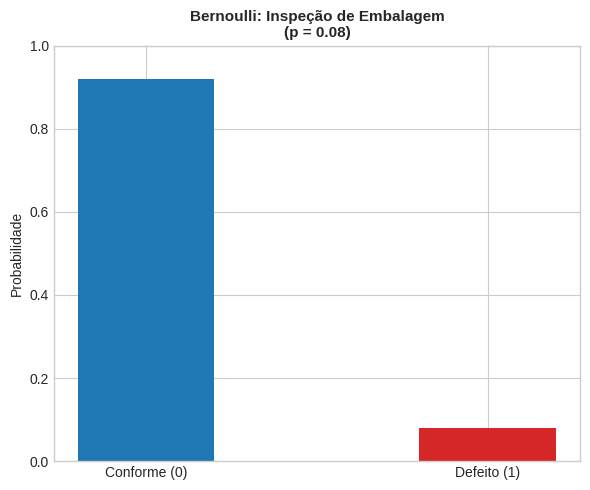

In [ ]:
plt.figure(figsize=(6, 5))
ax_bern = plt.gca()
x_bern = [0, 1]
y_bern = [prob_conforme, prob_defeito]
ax_bern.bar(x_bern, y_bern, color=["#1f77b4", "#d62728"], width=0.4)
ax_bern.set_xticks(x_bern)
ax_bern.set_xticklabels(["Conforme (0)", "Defeito (1)"])
ax_bern.set_ylabel("Probabilidade")
ax_bern.set_title("Bernoulli: Inspeção de Embalagem\n(p = 0.08)", fontsize=11, fontweight="bold")
ax_bern.set_ylim(0, 1)
plt.tight_layout()
plt.show()




## Gráfico Binomial

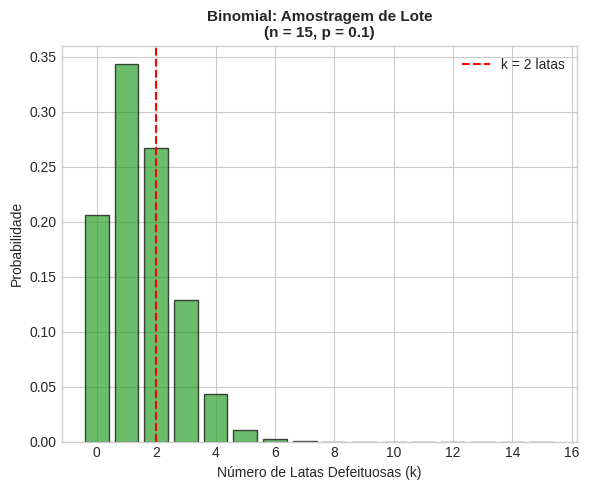

In [ ]:

plt.figure(figsize=(6, 5))
ax_binom = plt.gca()
k_binom = np.arange(0, n_latas + 1)
y_binom = binomial.pmf(k_binom)
ax_binom.bar(k_binom, y_binom, color="#2ca02c", alpha=0.7, edgecolor="black")
ax_binom.axvline(2, color="red", linestyle="--", label="k = 2 latas")
ax_binom.set_xlabel("Número de Latas Defeituosas (k)")
ax_binom.set_ylabel("Probabilidade")
ax_binom.set_title(f"Binomial: Amostragem de Lote\n(n = {n_latas}, p = {p_inconforme})", fontsize=11, fontweight="bold")
ax_binom.legend()
plt.tight_layout()
plt.show()



## Gráfico Poisson

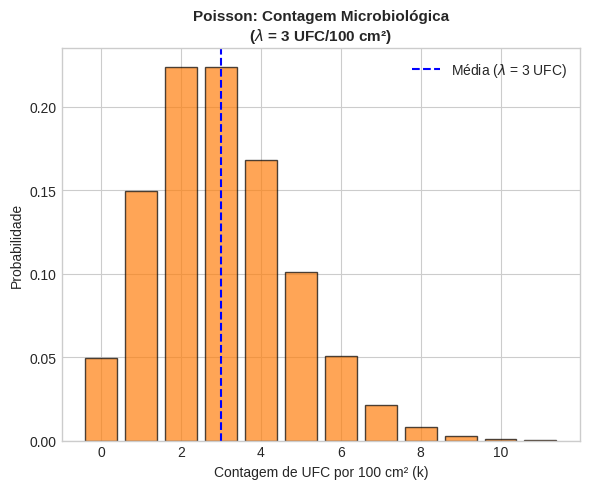

In [ ]:

plt.figure(figsize=(6, 5))
ax_poisson = plt.gca()
k_poisson = np.arange(0, 12)
y_poisson = poisson.pmf(k_poisson)
ax_poisson.bar(k_poisson, y_poisson, color="#ff7f0e", alpha=0.7, edgecolor="black")
ax_poisson.axvline(lambda_ufc, color="blue", linestyle="--", label=r"Média ($\lambda$ = 3 UFC)")
ax_poisson.set_xlabel("Contagem de UFC por 100 cm² (k)")
ax_poisson.set_ylabel("Probabilidade")
ax_poisson.set_title(r"Poisson: Contagem Microbiológica" "\n" r"($\lambda$ = 3 UFC/100 cm²)", fontsize=11, fontweight="bold")
ax_poisson.legend()
plt.tight_layout()
plt.show()